# 02. 카테고리 모멘텀 백테스트

**전략**: 카테고리별 12개월 모멘텀 신호 → 월 1회 리밸런싱  
**제약**: 위험자산 ≤ 70%, 월 회전율 ≥ 10%  
**기간**: 2021-01-01 ~ 2026-05-19 (워밍업 12개월 제외)  
**비교군**: 균등분산 BM, KODEX200, TIGER 미국S&P500

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys, os
import warnings
warnings.filterwarnings('ignore')

# ── 환경 감지 (Colab vs 로컬) ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # ★ Google Drive 내 프로젝트 경로 (필요시 수정)
    DRIVE_BASE = '/content/drive/MyDrive/졸업프로젝트/GAPS_대회'
    DATA_DIR   = '/content/drive/MyDrive/졸업프로젝트/GAPS_대회/data'
    OUT_DIR    = f'{DRIVE_BASE}/data'
    SRC_DIR    = f'{DRIVE_BASE}/src'
    # 한글 폰트
    os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
    import matplotlib.font_manager as fm
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    DATA_DIR = '/Users/seungbin/school/4-1/졸업프로젝트/data'
    OUT_DIR  = '/Users/seungbin/school/4-1/졸업프로젝트/GAPS_대회/data'
    SRC_DIR  = '/Users/seungbin/school/4-1/졸업프로젝트/GAPS_대회/src'
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
os.makedirs(OUT_DIR, exist_ok=True)

print(f'환경: {"Colab" if IN_COLAB else "로컬"}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'OUT_DIR  : {OUT_DIR}')
print('라이브러리 로드 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
환경: Colab
DATA_DIR : /content/drive/MyDrive/졸업프로젝트/GAPS_대회/data
OUT_DIR  : /content/drive/MyDrive/졸업프로젝트/GAPS_대회/data
라이브러리 로드 완료


In [5]:
# ── ETF 카테고리 매핑 ─────────────────────────────────────────────────────────
sys.path.append(SRC_DIR)
from etf_universe import ETF_LIST, RISK_CATEGORIES, SAFE_CATEGORIES

ticker2cat  = {e['ticker']: e['category']  for e in ETF_LIST}
ticker2risk = {e['ticker']: e['is_risk']   for e in ETF_LIST}
ticker2name = {e['ticker']: e['name']      for e in ETF_LIST}

ALL_CATEGORIES = RISK_CATEGORIES + SAFE_CATEGORIES
print('위험 카테고리:', RISK_CATEGORIES)
print('안전 카테고리:', SAFE_CATEGORIES)

위험 카테고리: ['fx_commodity', 'overseas_index', 'overseas_sector', 'domestic_index', 'domestic_sector']
안전 카테고리: ['mmf_ultrashort', 'overseas_bond_corp', 'overseas_bond', 'domestic_bond_corp', 'domestic_bond']


In [6]:
# ── 데이터 로드 및 전처리 ──────────────────────────────────────────────────────
close_raw = pd.read_parquet(f'{DATA_DIR}/etf_close_wide.parquet')
close_raw.index = pd.to_datetime(close_raw.index)
close_raw = close_raw.sort_index()

# 앞방향 채우기 (최대 5거래일, 공휴일 처리)
close = close_raw.ffill(limit=5)

# 월말 기준으로 리샘플
monthly = close.resample('ME').last()

# 백테스트 기간: 2020-01-01 이후 (12개월 워밍업 + 2021~ 실제)
monthly = monthly.loc['2020-01-31':]

# 월별 수익률
monthly_ret = monthly.pct_change().iloc[1:]  # 2020-02 ~

print(f'월별 가격 shape: {monthly.shape}')
print(f'월별 수익률 shape: {monthly_ret.shape}')
print(f'기간: {monthly_ret.index[0].date()} ~ {monthly_ret.index[-1].date()}')

월별 가격 shape: (77, 188)
월별 수익률 shape: (76, 188)
기간: 2020-02-29 ~ 2026-05-31


In [7]:
# ── 카테고리 평균 수익률 계산 ─────────────────────────────────────────────────
def get_category_returns(ret_df: pd.DataFrame) -> pd.DataFrame:
    """티커별 수익률 → 카테고리 평균 수익률"""
    cat_ret = {}
    for cat in ALL_CATEGORIES:
        tickers = [t for t in ret_df.columns if ticker2cat.get(t) == cat]
        tickers = [t for t in tickers if t in ret_df.columns]
        if tickers:
            cat_ret[cat] = ret_df[tickers].mean(axis=1)
    return pd.DataFrame(cat_ret)

cat_monthly_ret = get_category_returns(monthly_ret)
cat_monthly_price = (1 + cat_monthly_ret).cumprod()  # 카테고리 누적 수익

print('카테고리별 월평균 수익률:')
print((cat_monthly_ret.mean() * 100).round(2).to_string())

카테고리별 월평균 수익률:
fx_commodity          1.06
overseas_index        1.05
overseas_sector       1.51
domestic_index        2.33
domestic_sector       2.36
mmf_ultrashort        0.26
overseas_bond_corp    0.30
overseas_bond        -0.05
domestic_bond_corp    0.10
domestic_bond         0.05


In [8]:
# ── 모멘텀 전략 구현 ──────────────────────────────────────────────────────────
LOOKBACK_L   = 12    # 카테고리 선택: 12개월 모멘텀 (추세)
LOOKBACK_S   = 3     # ETF 선택: 3개월 모멘텀 (단기 로테이션 → 회전율 확보)
RISK_BUDGET  = 0.65  # 위험자산 비중 (65%, 제약 70% 이하)
SAFE_BUDGET  = 0.35  # 안전자산 비중
TOP_RISK     = 3     # 상위 위험 카테고리 선택 수
TOP_SAFE     = 2     # 상위 안전 카테고리 선택 수
TOP_ETF_FRAC = 0.33  # 카테고리 내 상위 ETF 비율 (33%)
COST         = 0.001 # 편도 거래비용 0.1%

def compute_momentum_signal(cat_price: pd.DataFrame, date_idx: int, lb: int) -> pd.Series:
    if date_idx < lb:
        return pd.Series(dtype=float)
    return (cat_price.iloc[date_idx] / cat_price.iloc[date_idx - lb] - 1).dropna()


def compute_cat_weights(momentum: pd.Series) -> dict:
    risk_mom = momentum[momentum.index.isin(RISK_CATEGORIES)].sort_values(ascending=False)
    safe_mom = momentum[momentum.index.isin(SAFE_CATEGORIES)].sort_values(ascending=False)
    weights = {}
    for cat in risk_mom.head(TOP_RISK).index:
        weights[cat] = RISK_BUDGET / TOP_RISK
    for cat in safe_mom.head(TOP_SAFE).index:
        weights[cat] = SAFE_BUDGET / TOP_SAFE
    return weights


def expand_to_etf_weights(cat_weights: dict, available_tickers: list,
                           etf_monthly: pd.DataFrame, date_idx: int) -> pd.Series:
    """카테고리 내 3개월 모멘텀 상위 33% ETF만 선택 → 월별 로테이션으로 회전율 확보"""
    etf_w = {}
    for cat, w in cat_weights.items():
        members = [t for t in available_tickers if ticker2cat.get(t) == cat
                   and t in etf_monthly.columns]
        if not members:
            continue
        # 3개월 ETF 모멘텀
        if date_idx >= LOOKBACK_S:
            mom3 = {}
            for t in members:
                col = etf_monthly[t]
                if date_idx < len(col) and date_idx - LOOKBACK_S >= 0:
                    p_end   = col.iloc[date_idx]
                    p_start = col.iloc[date_idx - LOOKBACK_S]
                    if pd.notna(p_end) and pd.notna(p_start) and p_start > 0:
                        mom3[t] = p_end / p_start - 1
            n_sel = max(1, int(len(mom3) * TOP_ETF_FRAC))
            selected = sorted(mom3, key=mom3.get, reverse=True)[:n_sel] if mom3 else members
        else:
            selected = members

        for t in selected:
            etf_w[t] = w / len(selected)

    total = sum(etf_w.values())
    return pd.Series({k: v / total for k, v in etf_w.items()})


# ── 백테스트 루프 ──────────────────────────────────────────────────────────────
backtest_start = '2021-01-31'
bt_dates = cat_monthly_price.loc[backtest_start:].index

portfolio_values   = [1.0]
monthly_returns_bt = []
turnover_log       = []
weight_log         = []
prev_weights       = pd.Series(dtype=float)

for i, date in enumerate(bt_dates[:-1]):
    idx = cat_monthly_price.index.get_loc(date)

    # 카테고리 12개월 모멘텀
    momentum = compute_momentum_signal(cat_monthly_price, idx, LOOKBACK_L)
    if momentum.empty:
        portfolio_values.append(portfolio_values[-1])
        monthly_returns_bt.append(0.0)
        continue

    # 카테고리 비중 결정
    cat_w = compute_cat_weights(momentum)

    # 카테고리 내 ETF 3개월 모멘텀 → 상위 33% 선택
    avail = monthly_ret.columns[monthly_ret.loc[bt_dates[i+1]].notna()].tolist()
    etf_monthly_idx = monthly.index.get_loc(date)
    etf_w = expand_to_etf_weights(cat_w, avail, monthly, etf_monthly_idx)

    # 회전율 & 거래비용
    turnover = (etf_w.reindex(prev_weights.index, fill_value=0) - prev_weights).abs().sum() / 2
    cost = float(turnover) * COST
    turnover_log.append({'date': bt_dates[i+1], 'turnover': float(turnover)})

    # 다음 달 포트폴리오 수익률
    next_ret = monthly_ret.loc[bt_dates[i+1]]
    port_ret = float((etf_w * next_ret.reindex(etf_w.index, fill_value=0)).sum()) - cost

    portfolio_values.append(portfolio_values[-1] * (1 + port_ret))
    monthly_returns_bt.append(port_ret)
    weight_log.append({'date': date, 'cat_weights': cat_w, 'momentum': momentum.to_dict()})
    prev_weights = etf_w

port_series     = pd.Series(portfolio_values, index=bt_dates[:len(portfolio_values)])
port_ret_series = pd.Series(monthly_returns_bt, index=bt_dates[1:len(portfolio_values)])
turnover_df     = pd.DataFrame(turnover_log).set_index('date')

print(f'백테스트 완료: {bt_dates[0].date()} ~ {bt_dates[-1].date()}')
print(f'평균 월 회전율: {turnover_df["turnover"].mean()*100:.1f}%  (대회 기준 ≥10%)')

백테스트 완료: 2021-01-31 ~ 2026-05-31
평균 월 회전율: 22.7%  (대회 기준 ≥10%)


In [9]:
# ── 벤치마크 계산 ─────────────────────────────────────────────────────────────

# BM1: 균등분산 (위험 65% + 안전 35%, 카테고리 내 균등)
risk_tickers = [t for t in monthly_ret.columns if ticker2risk.get(t) == True]
safe_tickers = [t for t in monthly_ret.columns if ticker2risk.get(t) == False]

bm1_ret = monthly_ret.loc[bt_dates[1]:].copy()
risk_w = RISK_BUDGET / len(risk_tickers)
safe_w = SAFE_BUDGET / len(safe_tickers)
bm1_weights = pd.Series(
    {t: risk_w for t in risk_tickers} | {t: safe_w for t in safe_tickers}
)
bm1_monthly = (bm1_ret[bm1_weights.index] * bm1_weights).sum(axis=1)
bm1_series = (1 + bm1_monthly).cumprod()

# BM2: KODEX 200 (국내 대형주)
bm2_monthly = monthly_ret.loc[bt_dates[1]:, '069500'].fillna(0)
bm2_series = (1 + bm2_monthly).cumprod()

# BM3: TIGER 미국S&P500
bm3_monthly = monthly_ret.loc[bt_dates[1]:, '360750'].fillna(0)
bm3_series = (1 + bm3_monthly).cumprod()

print('벤치마크 계산 완료')

벤치마크 계산 완료


In [10]:
# ── 성과 지표 함수 ────────────────────────────────────────────────────────────
def calc_metrics(ret_series: pd.Series, name: str) -> dict:
    n_months = len(ret_series)
    total_ret = (1 + ret_series).prod() - 1
    cagr = (1 + total_ret) ** (12 / n_months) - 1
    vol  = ret_series.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else 0

    cum = (1 + ret_series).cumprod()
    rolling_max = cum.cummax()
    dd = (cum / rolling_max - 1)
    mdd = dd.min()

    win_rate = (ret_series > 0).mean()

    return {
        '전략명':      name,
        '누적수익률':   f'{total_ret*100:.1f}%',
        'CAGR':       f'{cagr*100:.1f}%',
        '변동성(연)':   f'{vol*100:.1f}%',
        'Sharpe':     f'{sharpe:.2f}',
        'MDD':        f'{mdd*100:.1f}%',
        '월수익률>0':   f'{win_rate*100:.0f}%',
    }

metrics_table = pd.DataFrame([
    calc_metrics(port_ret_series, '카테고리 모멘텀 (우리)'),
    calc_metrics(bm1_monthly,     '균등분산 BM'),
    calc_metrics(bm2_monthly,     'KODEX 200'),
    calc_metrics(bm3_monthly,     'TIGER 미국S&P500'),
]).set_index('전략명')

print('=== 성과 지표 요약 ===')
print(metrics_table.to_string())

=== 성과 지표 요약 ===
                 누적수익률   CAGR 변동성(연) Sharpe     MDD 월수익률>0
전략명                                                       
카테고리 모멘텀 (우리)   161.8%  19.8%  17.8%   1.11  -13.0%    61%
균등분산 BM          88.3%  12.6%   9.5%   1.32   -9.5%    69%
KODEX 200       245.4%  26.2%  32.0%   0.82  -34.2%    55%
TIGER 미국S&P500  183.8%  21.6%  13.8%   1.57  -15.1%    67%


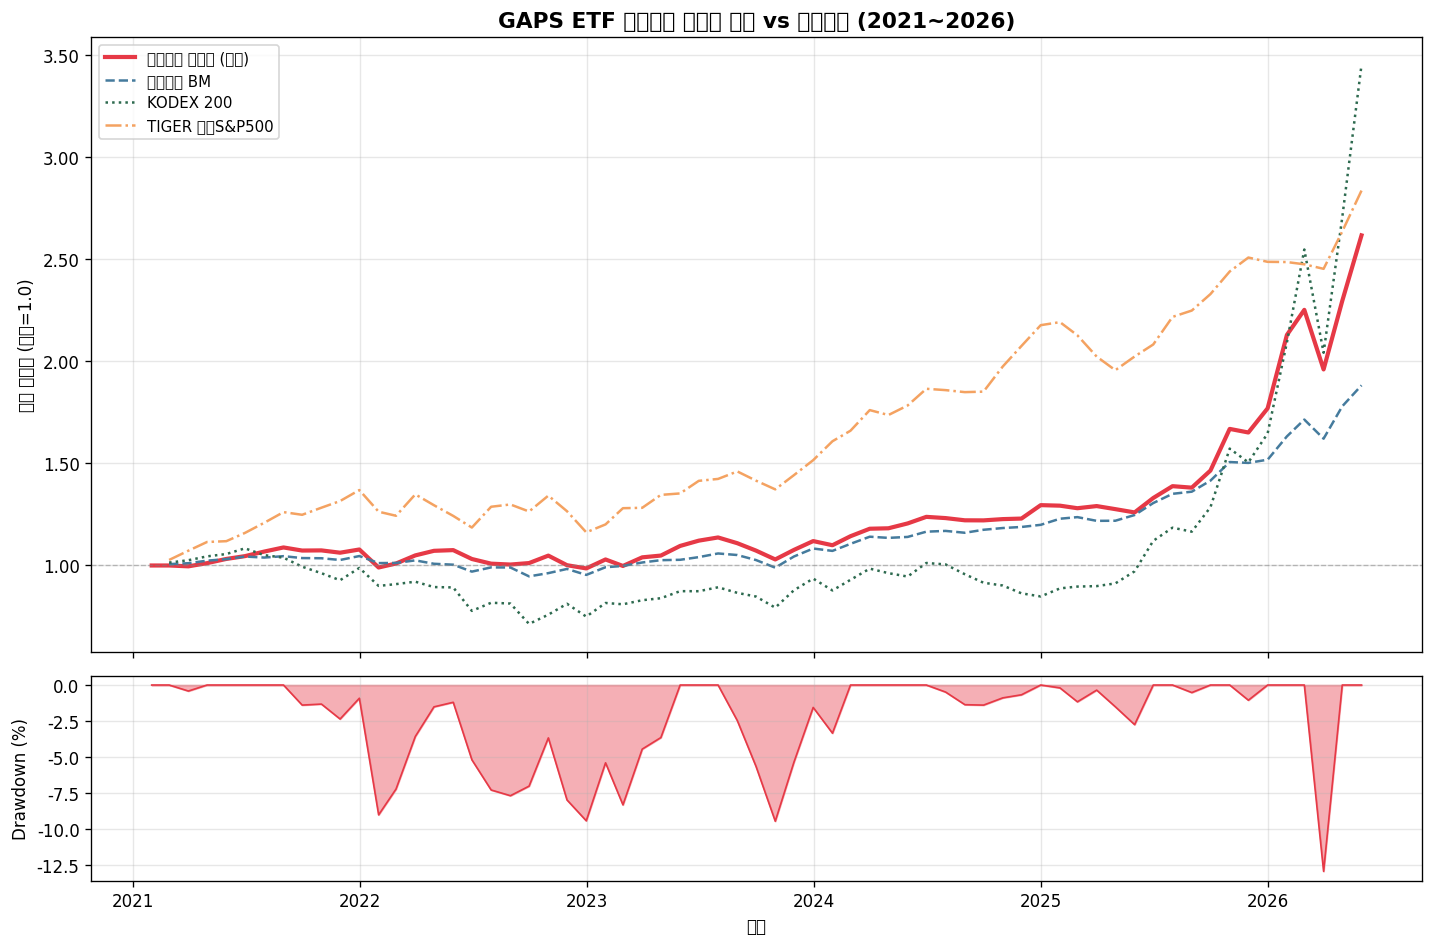

저장: backtest_cumulative.png


In [11]:
# ── 시각화 ①: 누적수익률 + 드로우다운 ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

common_idx = port_series.index
ax1.plot(common_idx, port_series.values,          lw=2.5, color='#E63946', label='카테고리 모멘텀 (우리)')
ax1.plot(bm1_series.index, bm1_series.values,     lw=1.5, color='#457B9D', label='균등분산 BM',      ls='--')
ax1.plot(bm2_series.index, bm2_series.values,     lw=1.5, color='#2D6A4F', label='KODEX 200',        ls=':')
ax1.plot(bm3_series.index, bm3_series.values,     lw=1.5, color='#F4A261', label='TIGER 미국S&P500', ls='-.')
ax1.axhline(1, color='gray', lw=0.8, ls='--', alpha=0.5)
ax1.set_ylabel('누적 수익률 (기준=1.0)')
ax1.set_title('GAPS ETF 카테고리 모멘텀 전략 vs 벤치마크 (2021~2026)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax1.grid(alpha=0.3)

# 드로우다운
cum_port = port_series
dd = (cum_port / cum_port.cummax() - 1) * 100
ax2.fill_between(dd.index, dd.values, 0, alpha=0.4, color='#E63946')
ax2.plot(dd.index, dd.values, lw=1, color='#E63946')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('날짜')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/backtest_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: backtest_cumulative.png')

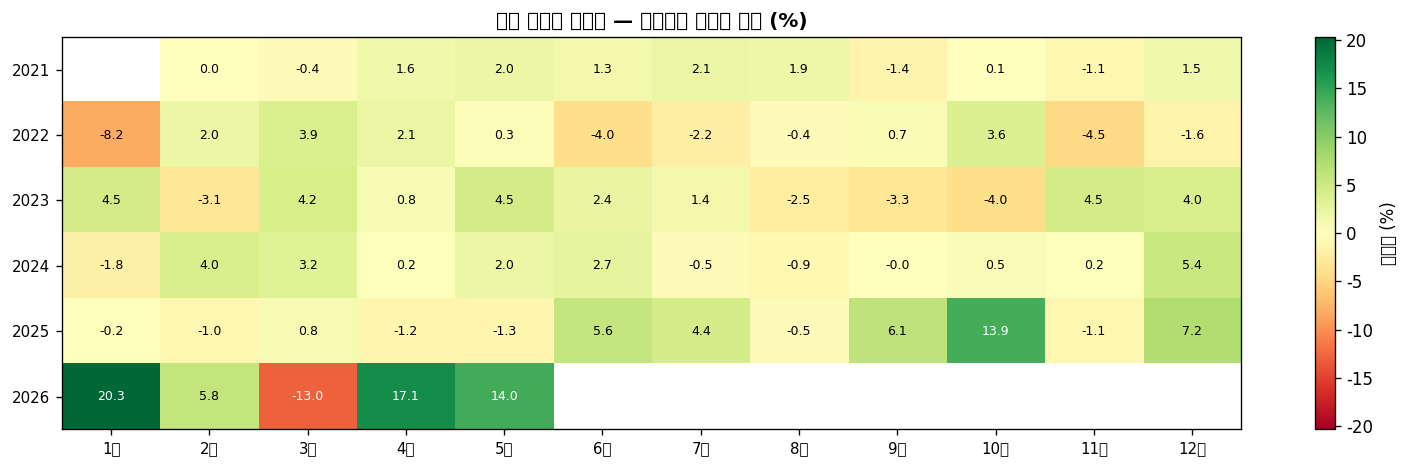

저장: backtest_heatmap.png


In [12]:
# ── 시각화 ②: 월별 수익률 히트맵 ─────────────────────────────────────────────
ret_pivot = port_ret_series.copy()
ret_df_hm = pd.DataFrame({
    'year':  ret_pivot.index.year,
    'month': ret_pivot.index.month,
    'ret':   ret_pivot.values * 100
})
heatmap_data = ret_df_hm.pivot(index='year', columns='month', values='ret')
heatmap_data.columns = ['1월','2월','3월','4월','5월','6월',
                         '7월','8월','9월','10월','11월','12월'][:len(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(13, 4))
vmax = max(abs(heatmap_data.values[~np.isnan(heatmap_data.values)]).max(), 5)
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title('월별 수익률 히트맵 — 카테고리 모멘텀 전략 (%)', fontsize=12, fontweight='bold')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=7.5, color='black' if abs(val) < vmax * 0.6 else 'white')

plt.colorbar(im, ax=ax, label='수익률 (%)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/backtest_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: backtest_heatmap.png')

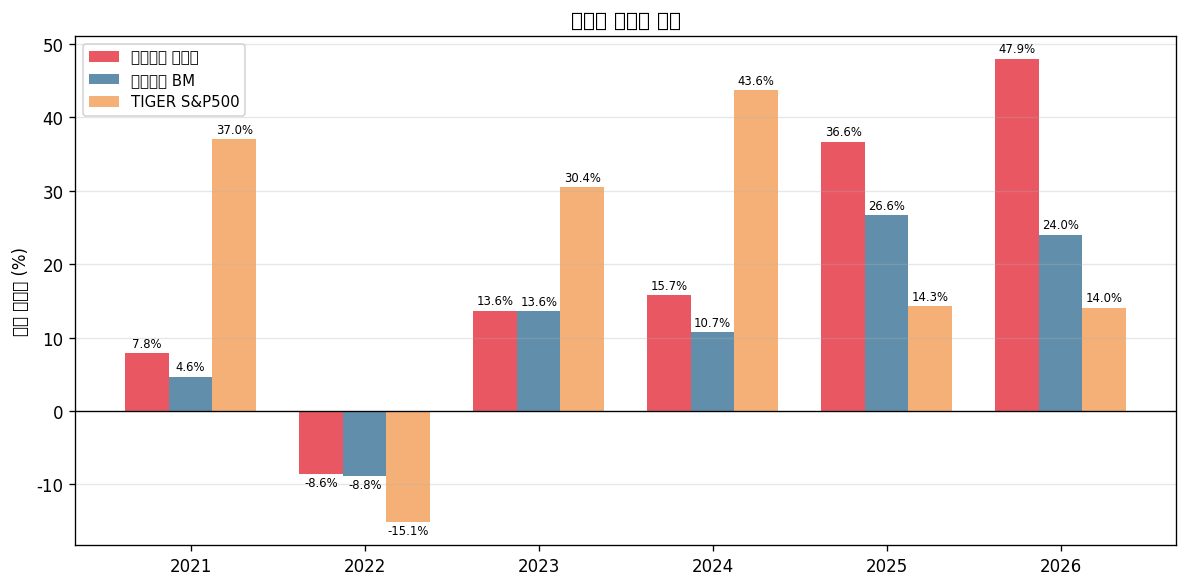

저장: backtest_annual.png


In [13]:
# ── 시각화 ③: 연도별 성과 막대 ───────────────────────────────────────────────
def annual_returns(ret_s: pd.Series) -> pd.Series:
    return ret_s.groupby(ret_s.index.year).apply(lambda x: (1+x).prod()-1) * 100

yr_port = annual_returns(port_ret_series)
yr_bm1  = annual_returns(bm1_monthly)
yr_bm3  = annual_returns(bm3_monthly)

years = yr_port.index
x = np.arange(len(years))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w,   yr_port.values, w, label='카테고리 모멘텀', color='#E63946', alpha=0.85)
ax.bar(x,       yr_bm1.reindex(years, fill_value=0).values, w, label='균등분산 BM',  color='#457B9D', alpha=0.85)
ax.bar(x + w,   yr_bm3.reindex(years, fill_value=0).values, w, label='TIGER S&P500', color='#F4A261', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('연간 수익률 (%)')
ax.set_title('연도별 수익률 비교', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    h = bar.get_height()
    if abs(h) > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.5 if h >= 0 else -2),
                f'{h:.1f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/backtest_annual.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: backtest_annual.png')

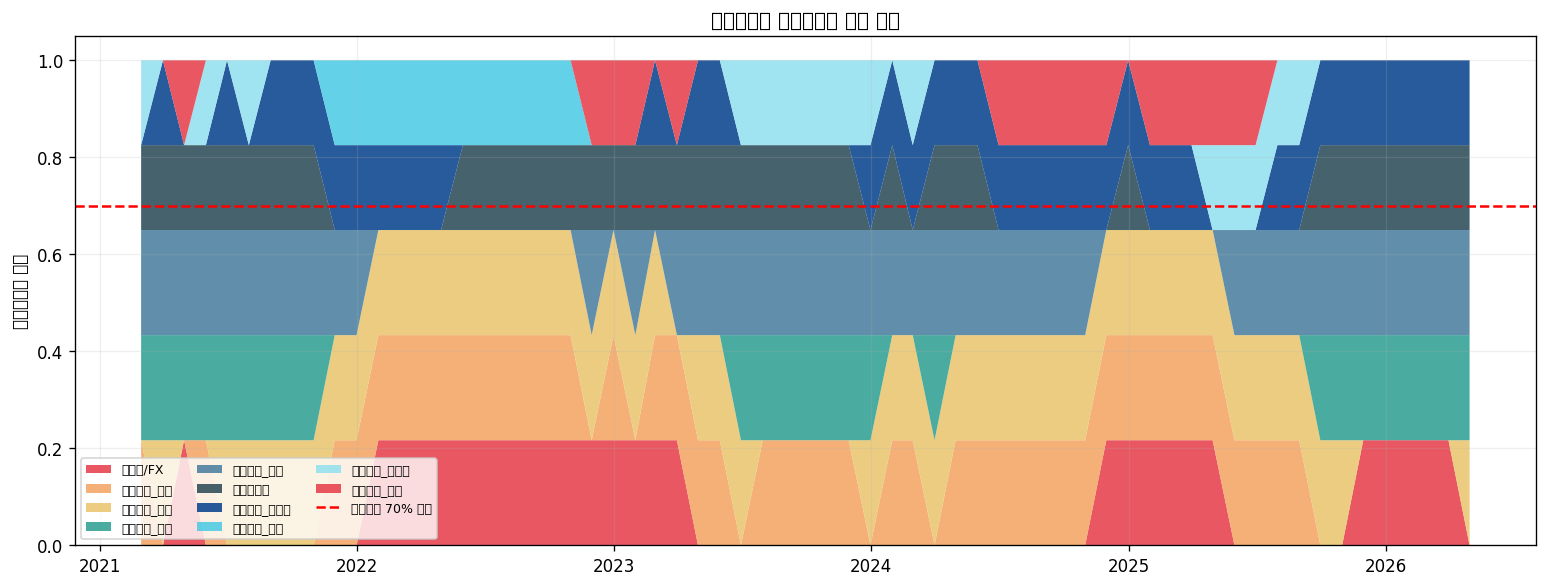

저장: backtest_allocation.png


In [14]:
# ── 시각화 ④: 카테고리 비중 변화 (Stacked Area) ───────────────────────────────
if weight_log:
    cat_w_history = pd.DataFrame([
        {'date': w['date'], **w['cat_weights']} for w in weight_log
    ]).set_index('date').fillna(0)

    risk_cols = [c for c in RISK_CATEGORIES if c in cat_w_history.columns]
    safe_cols = [c for c in SAFE_CATEGORIES if c in cat_w_history.columns]

    cat_labels = {
        'fx_commodity':       '원자재/FX',
        'overseas_index':     '해외주식_지수',
        'overseas_sector':    '해외주식_섹터',
        'domestic_index':     '국내주식_지수',
        'domestic_sector':    '국내주식_섹터',
        'mmf_ultrashort':     '초단기채권',
        'overseas_bond_corp': '해외채권_회사채',
        'overseas_bond':      '해외채권_종합',
        'domestic_bond_corp': '국내채권_회사채',
        'domestic_bond':      '국내채권_종합',
    }
    colors_risk = ['#e63946','#f4a261','#e9c46a','#2a9d8f','#457b9d']
    colors_safe = ['#264653','#023e8a','#48cae4','#90e0ef']

    fig, ax = plt.subplots(figsize=(13, 5))
    all_cols = risk_cols + safe_cols
    all_colors = colors_risk[:len(risk_cols)] + colors_safe[:len(safe_cols)]
    labels = [cat_labels.get(c, c) for c in all_cols]

    ax.stackplot(cat_w_history.index,
                 [cat_w_history[c].values for c in all_cols],
                 labels=labels, colors=all_colors, alpha=0.85)
    ax.axhline(0.70, color='red', lw=1.5, ls='--', label='위험자산 70% 한도')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('포트폴리오 비중')
    ax.set_title('카테고리별 포트폴리오 비중 변화', fontsize=12, fontweight='bold')
    ax.legend(loc='lower left', fontsize=7.5, ncol=3)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/backtest_allocation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: backtest_allocation.png')

In [15]:
# ── 최종 요약 출력 (투자계획서 복붙용) ──────────────────────────────────────────
print('=' * 60)
print('  GAPS 투자대회 백테스트 결과 요약 (2021.01 ~ 2026.05)')
print('=' * 60)
print(metrics_table.to_string())
print()
print(f'평균 월 회전율: {turnover_df["turnover"].mean()*100:.1f}%  (대회 기준 ≥10% ✓)')
print(f'위험자산 최대 비중: {RISK_BUDGET*100:.0f}%  (대회 제약 ≤70% ✓)')
print()
print('=== 연도별 수익률 ===')
yr_compare = pd.DataFrame({
    '모멘텀전략':   yr_port,
    '균등분산BM':   yr_bm1,
    'TIGER_SP500': yr_bm3,
}).round(1)
print(yr_compare.to_string())

# 결과 저장
metrics_table.to_csv(f'{OUT_DIR}/backtest_metrics.csv', encoding='utf-8-sig')
port_ret_series.to_frame('momentum_ret').to_csv(f'{OUT_DIR}/backtest_returns.csv', encoding='utf-8-sig')
print('\n결과 CSV 저장 완료')

  GAPS 투자대회 백테스트 결과 요약 (2021.01 ~ 2026.05)
                 누적수익률   CAGR 변동성(연) Sharpe     MDD 월수익률>0
전략명                                                       
카테고리 모멘텀 (우리)   161.8%  19.8%  17.8%   1.11  -13.0%    61%
균등분산 BM          88.3%  12.6%   9.5%   1.32   -9.5%    69%
KODEX 200       245.4%  26.2%  32.0%   0.82  -34.2%    55%
TIGER 미국S&P500  183.8%  21.6%  13.8%   1.57  -15.1%    67%

평균 월 회전율: 22.7%  (대회 기준 ≥10% ✓)
위험자산 최대 비중: 65%  (대회 제약 ≤70% ✓)

=== 연도별 수익률 ===
      모멘텀전략  균등분산BM  TIGER_SP500
2021    7.8     4.6         37.0
2022   -8.6    -8.8        -15.1
2023   13.6    13.6         30.4
2024   15.7    10.7         43.6
2025   36.6    26.6         14.3
2026   47.9    24.0         14.0

결과 CSV 저장 완료
